## Importing libraries

In [1]:
from dotenv import load_dotenv
import os
import time
import numpy as np
import pandas as pd
#from config.settings import get_settings
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from buscarpy import retrospective_h0
from scipy.stats import hypergeom

load_dotenv()
data_dir = os.getenv("data_dir")
print(data_dir)

/Users/ashleyrazo/Desktop/Thesis/biased-urn-stopping/data


## building the data 

In [2]:
import pyarrow.parquet as pq

# Dictionary to hold all data
data = {}

for review_folder in os.listdir(data_dir):
    review_path = os.path.join(data_dir, review_folder)
    if not os.path.isdir(review_path):
        continue
    review_id = review_folder.split('=')[1]
    data[review_id] = {}
    
    for run_folder in os.listdir(review_path):
        run_path = os.path.join(review_path, run_folder)
        if not os.path.isdir(run_path):
            continue
        run_id = run_folder.split('=')[1]
        
        # There should be exactly one Parquet file in the run folder
        parquet_files = [f for f in os.listdir(run_path) if f.endswith('.parquet')]
        if not parquet_files:
            continue
        
        parquet_path = os.path.join(run_path, parquet_files[0])
        df = pd.read_parquet(parquet_path)
        data[review_id][run_id] = df

# Preview the first run
first_review = list(data.keys())[0]
first_run = list(data[first_review].keys())[0]
print(f"Preview of review {first_review}, run {first_run}:")
display(data[first_review][first_run].head())


Preview of review 3, run 34:


,rec_id,screened_order,relevant,first_prediction,last_prediction,p_0.8,p_0.9,p_0.95,p_0.99
0,https://openalex.org/W1973648347,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,https://openalex.org/W2023505562,2.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,https://openalex.org/W1983509791,3.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,https://openalex.org/W2021967871,4.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,https://openalex.org/W2165113702,5.0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
 len(data), sum(len(data[r]) for r in data)

(26, 2600)

## function for rank-aware bayesian stopping rule

In [3]:
def run_bayesian_stopping(df, recall_target=0.95, stop_conf=0.99, min_n=20):
    """
    Bayesian stopping with a biased (rank-aware) urn model.
    Approximates Wallenius noncentral hypergeometric via exponential tilting.
    """
    N = len(df)
    total_relevant = df["relevant"].sum()

    p_store = []
    omega_store = []
    stop_n = None

    for n in range(1, N+1):
        k = df["relevant"][:n].sum()

        # If nothing found yet, posterior is trivial
        if k == 0:
            p_store.append(0.0)
            omega_store.append(1.0)
            continue

        # Possible total relevant values
        K_vals = np.arange(k, min(N, int(k / recall_target) + 500) + 1)

        # Baseline (random draw) likelihood
        likelihood = hypergeom.pmf(k, N, K_vals, n)

        # Estimate ranking strength (ω)
        # Observed prevalence vs expected prevalence
        observed_rate = k / n
        base_rate = K_vals / N

        enrichment = observed_rate / np.maximum(base_rate, 1e-6)

        # Stabilize early estimates
        if n < min_n:
            omega = 1.0
        else:
            # median enrichment gives robust estimate
            omega = np.median(enrichment)

        omega = np.clip(omega, 1.0, 50.0)   # avoid insane weights
        beta = np.log(omega)

        # Bias the likelihood (Wallenius approx)
        likelihood = likelihood * np.exp(beta * k)

        # Uniform prior over K
        posterior = likelihood
        posterior /= posterior.sum()

        # Compute stopping probability 
        max_K = int(np.floor(k / recall_target))
        prob_recall = posterior[K_vals <= max_K].sum()

        p_store.append(prob_recall)
        omega_store.append(omega)

        if stop_n is None and prob_recall >= stop_conf:
            stop_n = n
            break

    true_recall_at_stop = (
        df["relevant"][:stop_n].sum() / total_relevant
        if stop_n is not None else None
    )

    return {
        "stop_n": stop_n,
        "true_recall": true_recall_at_stop,
        "p_curve": p_store,
        "omega_curve": omega_store
    }

## baseline stop helper function

In [4]:
def run_baseline_h0(df, recall_target=0.95, confidence=0.95):

    N = len(df)

    baseline_out = retrospective_h0(
        labels_=df["relevant"].values,
        N=N,
        recall_target=recall_target,
        bias=1,
        batch_size=1,
        confidence_level=confidence,
        plot=False
    )

    threshold = 1 - confidence
    stop_n = N   # default: screen everything

    for b, p in zip(baseline_out["batch_sizes"], baseline_out["p"]):
        if p < threshold:
            stop_n = b
            break

    total_relevant = df["relevant"].sum()
    true_recall = df["relevant"][:stop_n].sum() / total_relevant

    return {
        "stop_n": stop_n,
        "true_recall": true_recall
    }

## Apply this to all runs and datasets

In [ ]:
confidence_levels = [0.90, 0.95, 0.99]

results = []
t0 = time.time()

total_runs = sum(len(data[r]) for r in data) * len(confidence_levels)
run_counter = 0

for review_id in data:
    print("Review", review_id)

    for run_id in data[review_id]:
        df = data[review_id][run_id]
        true_K = df["relevant"].sum()
        N = len(df)

        for conf in confidence_levels:
            run_counter += 1
            print(f"  Run {run_id} | conf={conf}  ({run_counter}/{total_runs})  elapsed {time.time()-t0:.1f}s")

            
            # --- Bayesian stopping ---
            out_bayes = run_bayesian_stopping(df, stop_conf=conf)

            stop_n_bayes = out_bayes["stop_n"]
            true_recall_bayes = out_bayes["true_recall"]

            omega_at_stop = None
            if stop_n_bayes is not None:
                omega_at_stop = out_bayes["omega_curve"][stop_n_bayes - 1]


            # --- Baseline stopping (via helper function) ---
            baseline_out = run_baseline_h0(df, confidence=conf)

            stop_n_baseline = baseline_out["stop_n"]
            true_recall_baseline = baseline_out["true_recall"]

            results.append({
                "review_id": review_id,
                "run_id": run_id,
                "N": N,
                "true_K": true_K,

                # Bayesian
                "stop_n_bayes": stop_n_bayes,
                "true_recall_bayes": true_recall_bayes,
                "omega": omega_at_stop,

                # Baseline
                "stop_n_baseline": stop_n_baseline,
                "true_recall_baseline": true_recall_baseline,
    
                "confidence": conf
})


        # crash-safe checkpoint
        pd.DataFrame(results).to_csv("bayes_results_partial.csv", index=False)

results_df = pd.DataFrame(results)
results_df.to_csv("bayes_results_full.csv", index=False)

print("DONE. Total time:", time.time() - t0)
print("Review:", review_id, "Run:", run_id, "N:", N)
print("Bayesian time:", bayes_time, " | N:", N)

Review 3
  Run 34 | conf=0.9  (1/7800)  elapsed 0.0s
  Run 34 | conf=0.95  (2/7800)  elapsed 4.3s
  Run 34 | conf=0.99  (3/7800)  elapsed 8.7s
  Run 33 | conf=0.9  (4/7800)  elapsed 13.1s
  Run 33 | conf=0.95  (5/7800)  elapsed 17.3s
  Run 33 | conf=0.99  (6/7800)  elapsed 21.6s
  Run 56 | conf=0.9  (7/7800)  elapsed 25.9s
  Run 56 | conf=0.95  (8/7800)  elapsed 30.0s
  Run 56 | conf=0.99  (9/7800)  elapsed 34.2s
  Run 69 | conf=0.9  (10/7800)  elapsed 38.4s
  Run 69 | conf=0.95  (11/7800)  elapsed 42.7s
  Run 69 | conf=0.99  (12/7800)  elapsed 47.0s
  Run 5 | conf=0.9  (13/7800)  elapsed 51.4s
  Run 5 | conf=0.95  (14/7800)  elapsed 55.6s
  Run 5 | conf=0.99  (15/7800)  elapsed 59.8s
  Run 51 | conf=0.9  (16/7800)  elapsed 63.9s
  Run 51 | conf=0.95  (17/7800)  elapsed 68.1s
  Run 51 | conf=0.99  (18/7800)  elapsed 72.4s
  Run 2 | conf=0.9  (19/7800)  elapsed 76.7s
  Run 2 | conf=0.95  (20/7800)  elapsed 81.0s
  Run 2 | conf=0.99  (21/7800)  elapsed 85.3s
  Run 67 | conf=0.9  (22/7800

In [7]:
import time

df = data[some_review_id][some_run_id]

start = time.time()
out = run_bayesian_stopping(df, stop_conf=0.95)
print("Time for 1 run:", time.time() - start)

NameError: name 'some_review_id' is not defined

In [20]:
results_df = pd.read_csv("bayes_results_partial.csv")

print("Runs completed so far:", len(results_df))
print(results_df.columns)
results_df.head()

Runs completed so far: 693
Index(['review_id', 'run_id', 'N', 'true_K', 'stop_n_bayes',
       'true_recall_bayes', 'omega', 'stop_n_baseline', 'true_recall_baseline',
       'confidence'],
      dtype='object')


,review_id,run_id,N,true_K,stop_n_bayes,true_recall_bayes,omega,stop_n_baseline,true_recall_baseline,confidence
0,3,34,1908,15,1896,1.0,1.0,1853,1.0,0.90
1,3,34,1908,15,1902,1.0,1.0,1881,1.0,0.95
2,3,34,1908,15,1907,1.0,1.0,1903,1.0,0.99
3,3,33,1908,15,1896,1.0,1.0,1859,1.0,0.90
4,3,33,1908,15,1902,1.0,1.0,1884,1.0,0.95


## Reliability and efficiency analysis

In [21]:
results_df = pd.DataFrame(results)

# --- Reliability ---
results_df["miss_bayes"] = results_df["true_recall_bayes"] < 0.95
results_df["miss_baseline"] = results_df["true_recall_baseline"] < 0.95

# --- Work saved ---
results_df["work_saved_bayes"] = 1 - results_df["stop_n_bayes"] / results_df["N"]
results_df["work_saved_baseline"] = 1 - results_df["stop_n_baseline"] / results_df["N"]

# --- Additional work saved ---
results_df["additional_work_saved"] = (
    results_df["work_saved_bayes"] -
    results_df["work_saved_baseline"]
)

summary = (
    results_df
    .groupby("confidence")
    .agg(
        miss_rate_bayes=("miss_bayes", "mean"),
        miss_rate_baseline=("miss_baseline", "mean"),
        mean_work_saved_bayes=("work_saved_bayes", "mean"),
        mean_work_saved_baseline=("work_saved_baseline", "mean"),
        mean_additional=("additional_work_saved", "mean"),
        median_additional=("additional_work_saved", "median")
    )
)

summary

,miss_rate_bayes,miss_rate_baseline,mean_work_saved_bayes,mean_work_saved_baseline,mean_additional,median_additional
confidence,,,,,,
0.90,0.00431,0.043103,0.016879,0.125114,-0.108235,-0.121262
0.95,0.00000,0.021645,0.011185,0.081455,-0.070269,-0.084346
0.99,0.00000,0.000000,0.004847,0.038858,-0.034011,-0.036916


### How early does it stop?

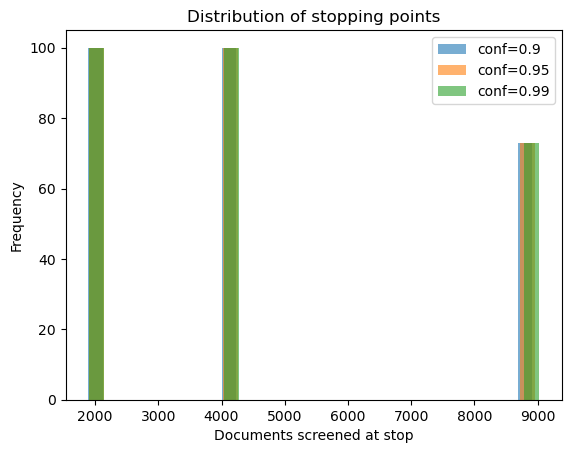

In [8]:
import matplotlib.pyplot as plt

for conf in results_df["confidence"].unique():
    subset = results_df[results_df["confidence"] == conf]
    plt.hist(subset["stop_n"], bins=30, alpha=0.6, label=f"conf={conf}")

plt.xlabel("Documents screened at stop")
plt.ylabel("Frequency")
plt.title("Distribution of stopping points")
plt.legend()
plt.show()